# 02 - MACD + 量比策略研究与回测

策略思路：DIF上穿DEA且量比放大时买入，DIF下穿DEA或量比萎缩时卖出。

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
for p in [cwd / 'src', cwd.parent / 'src']:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from quant_research.db import query_df

In [2]:
symbol = 'US:MSFT'
start_date = '2023-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
fee_rate = 0.0003
slippage = 0.001
vr_window = 5
vr_buy_th = 1.2
vr_sell_th = 0.8

In [3]:
df = query_df(f"""
select trade_date, symbol, close, volume
from daily_bars
where symbol = '{symbol}'
  and trade_date between toDate('{start_date}') and toDate('{end_date}')
order by trade_date
""")
df['trade_date'] = pd.to_datetime(df['trade_date'])
df.head()

,trade_date,symbol,close,volume
0,2026-02-17,US:MSFT,395.956238,32078800.0
1,2026-02-18,US:MSFT,398.690002,23223400.0
2,2026-02-19,US:MSFT,398.459991,28234000.0
3,2026-02-20,US:MSFT,397.230011,34015200.0
4,2026-02-23,US:MSFT,384.470001,43238300.0


In [4]:
def add_macd_vr_signal(data: pd.DataFrame, vr_window: int, vr_buy_th: float, vr_sell_th: float):
    out = data.copy()
    out['ema12'] = out['close'].ewm(span=12, adjust=False).mean()
    out['ema26'] = out['close'].ewm(span=26, adjust=False).mean()
    out['dif'] = out['ema12'] - out['ema26']
    out['dea'] = out['dif'].ewm(span=9, adjust=False).mean()
    out['macd_hist'] = (out['dif'] - out['dea']) * 2

    out['vol_ma'] = out['volume'].rolling(vr_window).mean()
    out['vol_ratio'] = out['volume'] / (out['vol_ma'] + 1e-12)

    cross_up = (out['dif'] > out['dea']) & (out['dif'].shift(1) <= out['dea'].shift(1))
    cross_down = (out['dif'] < out['dea']) & (out['dif'].shift(1) >= out['dea'].shift(1))

    out['buy_signal'] = (cross_up & (out['vol_ratio'] >= vr_buy_th)).astype(int)
    out['sell_signal'] = (cross_down | (out['vol_ratio'] <= vr_sell_th)).astype(int)
    return out


def backtest(data: pd.DataFrame):
    out = add_macd_vr_signal(data, vr_window, vr_buy_th, vr_sell_th)
    out['ret'] = out['close'].pct_change().fillna(0.0)

    pos = np.zeros(len(out), dtype=int)
    for i in range(1, len(out)):
        pos[i] = pos[i - 1]
        if out['buy_signal'].iat[i] == 1:
            pos[i] = 1
        if out['sell_signal'].iat[i] == 1:
            pos[i] = 0

    out['position'] = pd.Series(pos, index=out.index).shift(1).fillna(0).astype(int)
    out['trade_flag'] = out['position'].diff().abs().fillna(0)
    cost = out['trade_flag'] * (fee_rate + slippage)

    out['strategy_ret'] = out['position'] * out['ret'] - cost
    out['strategy_curve'] = (1 + out['strategy_ret']).cumprod()
    out['benchmark_curve'] = (1 + out['ret']).cumprod()

    days = max(len(out), 1)
    ann_factor = 252 / days
    total_return = out['strategy_curve'].iat[-1] - 1
    cagr = (1 + total_return) ** ann_factor - 1
    mdd = (out['strategy_curve'] / out['strategy_curve'].cummax() - 1).min()
    sharpe = np.sqrt(252) * out['strategy_ret'].mean() / (out['strategy_ret'].std() + 1e-12)

    metrics = {
        'total_return': float(total_return),
        'cagr': float(cagr),
        'max_drawdown': float(mdd),
        'sharpe': float(sharpe),
        'num_trades': int(out['trade_flag'].sum()),
    }
    return out, metrics

In [5]:
bt, metrics = backtest(df)
pd.DataFrame([{'symbol': symbol, **metrics}])

,symbol,total_return,cagr,max_drawdown,sharpe,num_trades
0,US:MSFT,0.0,0.0,0.0,0.0,0


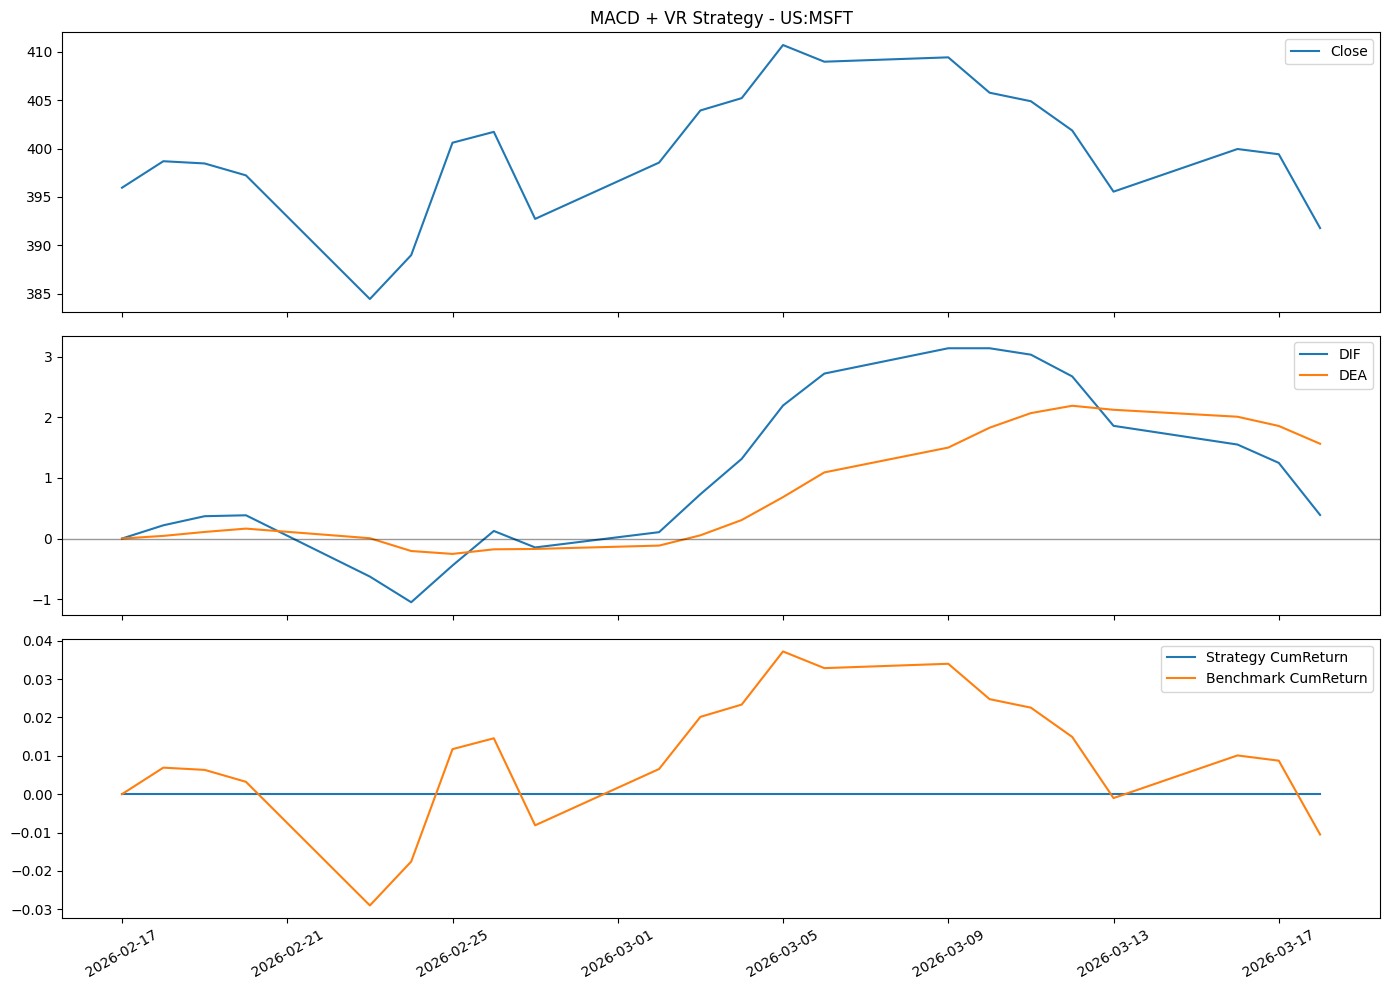

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(bt['trade_date'], bt['close'], label='Close')
axes[0].set_title(f'MACD + VR Strategy - {symbol}')
axes[0].legend()

axes[1].plot(bt['trade_date'], bt['dif'], label='DIF')
axes[1].plot(bt['trade_date'], bt['dea'], label='DEA')
axes[1].axhline(0, color='black', linewidth=1, alpha=0.4)
axes[1].legend()

axes[2].plot(bt['trade_date'], bt['strategy_curve'] - 1, label='Strategy CumReturn')
axes[2].plot(bt['trade_date'], bt['benchmark_curve'] - 1, label='Benchmark CumReturn')
axes[2].legend()

plt.xticks(rotation=30)
plt.tight_layout()